# 25. Exploratory E1 — a second lens: spillovers (Diebold–Yilmaz)
*Exploratory: added after the main results (PREREGISTRATION.md, Amendment A1).*

SHAP asked which markets the **neural network** listens to. The **Diebold–Yilmaz spillover index** asks a simple **linear model** of the three markets — a **VAR** (vector autoregression) — how much of the uncertainty in forecasting the ISEQ's volatility comes from shocks in each market. Do the two tools tell the same story?

* **Needs:** `work/dataset.csv`, `work/lstm_forecasts.csv`, `results/shap_channel_shares.csv`. **Makes:** nothing new.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [2]:
from pandas import read_csv
dataset = read_csv(folder + 'work/dataset.csv', index_col=0, parse_dates=True)
dataset = dataset.loc[:'2023-08-31']        # main sample
print(dataset.shape)

(5243, 17)


## The data: log 5-day volatility of the three markets

In [3]:
from numpy import log
vol = dataset[['r2', 'us_r2', 'euro_r2']].rolling(5).mean()
vol = log(vol.clip(lower=0.00000001)).dropna()
vol.columns = ['domestic', 'US', 'euro']
vol.head()

,domestic,US,euro
2003-01-08,-8.465628,-7.926475,-6.543001
2003-01-09,-9.875297,-8.415340,-7.642076
2003-01-10,-10.543747,-8.415552,-7.648445
2003-01-13,-10.439618,-9.003311,-7.814633
2003-01-14,-10.427553,-9.018588,-7.838947


## A VAR — one regression per market
Each market's volatility today is regressed on the last **4 days** of **all three** markets. `statsmodels` builds and fits it in the usual two steps:

In [4]:
from statsmodels.tsa.api import VAR
warnings.filterwarnings('ignore')     # statsmodels switches some warnings back on: hide them again
model = VAR(vol)              # building
best_model = model.fit(4)     # training: 4 days of lags
best_model.params.round(3)

,domestic,US,euro
const,-0.779,-0.577,-0.855
L1.domestic,0.855,0.021,-0.011
L1.US,0.095,0.878,0.084
L1.euro,0.017,0.040,0.862
L2.domestic,0.026,0.015,0.022
L2.US,-0.021,0.028,-0.030
L2.euro,-0.003,-0.008,0.026
L3.domestic,0.002,-0.003,0.003
L3.US,-0.006,0.001,0.014
L3.euro,-0.016,-0.009,-0.002


## How a shock travels, and who causes the uncertainty
* `ma_rep(9)` gives 10 tables $A_0 … A_9$: how a shock today shows up 0, 1, … 9 days later.
* `sigma_u` tells how the three markets' daily surprises move together.
* The **generalized variance decomposition** (Pesaran & Shin, 1998) adds up, over 10 days, how much of each market's forecast uncertainty comes from shocks in each market. `@` is matrix multiplication.

In [5]:
from numpy import asarray, zeros
A = best_model.ma_rep(9)
sigma = asarray(best_model.sigma_u)

share = zeros((3, 3))
for i in range(3):                      # the market whose forecast we look at
    denominator = 0
    for h in range(10):
        denominator = denominator + (A[h] @ sigma @ A[h].T)[i, i]
    for j in range(3):                  # the market the shock comes from
        numerator = 0
        for h in range(10):
            numerator = numerator + (A[h] @ sigma)[i, j] ** 2
        share[i, j] = numerator / sigma[j, j] / denominator

for i in range(3):                      # rescale each row to add up to 1
    share[i] = share[i] / share[i].sum()

from pandas import DataFrame
table = DataFrame(share * 100, index=['domestic', 'US', 'euro'], columns=['from domestic', 'from US', 'from euro'])
table.round(2)

,from domestic,from US,from euro
domestic,63.98,17.84,18.18
US,12.50,69.49,18.01
euro,15.16,20.33,64.51


Read the first row: of the uncertainty in forecasting **Irish** volatility, about 64% comes from Irish shocks, 18% from the US and 18% from the euro area. The **total spillover index** is the average share that comes from *other* markets:

In [6]:
total = (share.sum() - share[0, 0] - share[1, 1] - share[2, 2]) / 3 * 100
print('total spillover index =', round(total, 1), '%')

total spillover index = 34.0 %


## Over time: a 200-day rolling window
The same calculation on the 200 days up to each day, moving one day at a time (about 5,000 VARs — a minute or two). The steps above go into a function:

In [7]:
def iseq_row(data200):
    best_model = VAR(data200).fit(4)
    A = best_model.ma_rep(9)
    sigma = asarray(best_model.sigma_u)
    share = zeros((3, 3))
    for i in range(3):
        denominator = 0
        for h in range(10):
            denominator = denominator + (A[h] @ sigma @ A[h].T)[i, i]
        for j in range(3):
            numerator = 0
            for h in range(10):
                numerator = numerator + (A[h] @ sigma)[i, j] ** 2
            share[i, j] = numerator / sigma[j, j] / denominator
    for i in range(3):
        share[i] = share[i] / share[i].sum()
    total = (share.sum() - share[0, 0] - share[1, 1] - share[2, 2]) / 3 * 100
    return [share[0, 0], share[0, 1], share[0, 2], total]


rows = []
for end in range(199, len(vol)):
    rows.append(iseq_row(vol.iloc[end - 199:end + 1]))
    if end % 1000 == 0:
        print(end, 'of', len(vol))
rolling = DataFrame(rows, index=vol.index[199:], columns=['domestic', 'US', 'euro', 'total'])
rolling.tail()

1000 of 5239


2000 of 5239


3000 of 5239


4000 of 5239


5000 of 5239


,domestic,US,euro,total
2023-08-25,0.653483,0.044505,0.302011,27.375130
2023-08-28,0.640155,0.067100,0.292745,27.376222
2023-08-29,0.641766,0.061393,0.296842,27.148736
2023-08-30,0.642433,0.061007,0.296560,27.119249
2023-08-31,0.642338,0.061260,0.296403,27.212744


<Axes: title={'center': 'Share of ISEQ forecast uncertainty from the US and the euro area (200-day windows)'}>

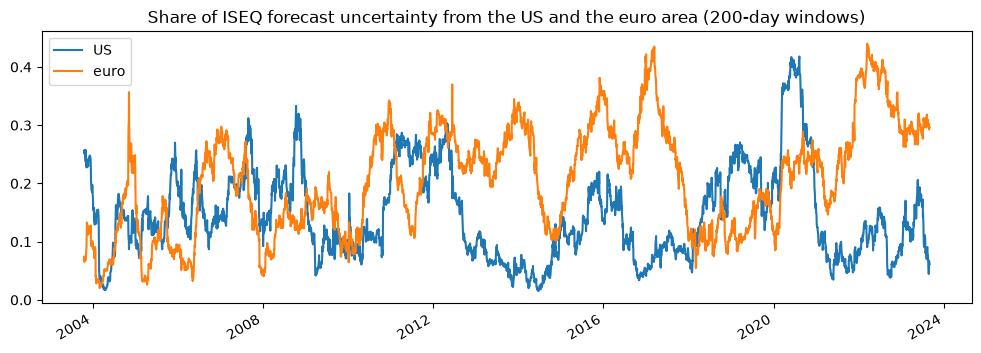

In [8]:
rolling[['US', 'euro']].plot(figsize=(12, 4), title='Share of ISEQ forecast uncertainty from the US and the euro area (200-day windows)')

## Compare with SHAP on the same days
The SHAP days were every day in the crisis windows plus every 10th calm day.

In [9]:
from pandas import read_csv
lstm = read_csv(folder + 'work/lstm_forecasts.csv', index_col=0, parse_dates=True)
windows = dataset.loc[lstm.index, 'window']
calm_days = lstm.index[windows == 'calm'][::10]
crisis_days = lstm.index[windows.isin(['Global Financial Crisis', 'Irish sovereign debt crisis', 'COVID-19', 'War / energy shock 2022'])]
shap_days = crisis_days.union(calm_days)
dy = rolling.loc[shap_days].groupby(windows.loc[shap_days]).mean()
order = ['calm', 'Global Financial Crisis', 'Irish sovereign debt crisis', 'COVID-19', 'War / energy shock 2022']
dy = dy.loc[order]
dy.round(3)

,domestic,US,euro,total
window,,,,
calm,0.655,0.124,0.221,32.594
Global Financial Crisis,0.672,0.199,0.129,32.512
Irish sovereign debt crisis,0.551,0.206,0.243,42.682
COVID-19,0.427,0.354,0.219,49.463
War / energy shock 2022,0.512,0.107,0.381,42.667


In [10]:
shap = read_csv(folder + 'results/shap_channel_shares.csv')
shap_share = shap.pivot(index='window', columns='channel', values='share').loc[order, ['domestic', 'US', 'euro']]
shap_share.round(3)

channel,domestic,US,euro
window,,,
calm,0.523,0.266,0.211
Global Financial Crisis,0.482,0.299,0.219
Irish sovereign debt crisis,0.512,0.252,0.236
COVID-19,0.488,0.332,0.180
War / energy shock 2022,0.540,0.317,0.143


## Do they agree?
1. For the 4 crises × 2 foreign markets: does the share **move the same way** (up or down) from calm in both tools?
2. In each of the 5 windows: do both tools put the **same foreign market first**?

In [11]:
same_direction = 0
for window in ['Global Financial Crisis', 'Irish sovereign debt crisis', 'COVID-19', 'War / energy shock 2022']:
    for channel in ['US', 'euro']:
        shap_up = shap_share.loc[window, channel] > shap_share.loc['calm', channel]
        dy_up = dy.loc[window, channel] > dy.loc['calm', channel]
        if shap_up == dy_up:
            same_direction = same_direction + 1
print('same direction of change:', same_direction, 'of 8')

same_order = 0
for window in order:
    shap_us_first = shap_share.loc[window, 'US'] > shap_share.loc[window, 'euro']
    dy_us_first = dy.loc[window, 'US'] > dy.loc[window, 'euro']
    if shap_us_first == dy_us_first:
        same_order = same_order + 1
print('same foreign market first:', same_order, 'of 5')

same direction of change: 4 of 8
same foreign market first: 2 of 5


**Weak agreement.** Both tools see the US share highest in COVID-19, but they differ most in 2022 (the spillover euro share rises, SHAP's falls). The two tools measure different things — a linear model of volatility only, against a non-linear network that also uses the direction of moves — so the 'fingerprints' depend on the lens. That is a finding in itself, to discuss in your own words.